**GOALS**:
**Correlation Analysis Mental Health and Lifestyle**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#IMPORT DATA 
df = pd.read_csv(r"D:\Data Science projects\Teen Mental Health\Dataset\Teen_Mental_Health_Dataset.csv")
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [4]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [5]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [13]:
df['platform_usage'] = df['platform_usage'].str.lower().str.strip()

In [15]:
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,tiktok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,tiktok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [35]:
print(df['gender'].unique())
print(df['platform_usage'].unique())
print(df['social_interaction_level'].unique())

['male' 'female']
['instagram' 'tiktok' 'both']
['low' 'high' 'medium']


In [37]:
gender_mapping = {
    'male': 0,
    'female' : 1
}
platform_usage_mapping = {
    'instagram': 0,
    'tiktok': 1,
    'both': 2
}

social_interaction_level_mapping = {
    'low': 0,
    'medium': 1,
    'high': 2
}

In [39]:
df['gender'] = df['gender'].map(gender_mapping)
df['platform_usage'] = df['platform_usage'].map(platform_usage_mapping)
df['social_interaction_level'] = df['social_interaction_level'].map(social_interaction_level_mapping)

In [41]:
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,0,7.9,0,7.4,2.9,3.01,1.5,0,2,2,1,0
1,19,1,1.9,1,8.0,2.9,3.22,0.8,2,8,1,10,0
2,17,1,1.3,0,7.6,0.5,3.92,0.0,2,2,4,2,0
3,15,0,7.4,1,6.9,1.6,3.48,0.8,1,1,7,9,0
4,15,1,4.7,2,4.9,3.0,2.37,1.4,1,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,1,6.8,0,6.6,2.0,2.76,1.0,0,3,4,4,0
1196,16,0,2.3,2,8.0,1.9,2.12,0.4,2,7,4,4,0
1197,14,1,1.7,2,8.7,0.7,3.98,0.8,2,1,1,1,0
1198,15,0,3.9,2,8.5,2.1,3.19,0.6,2,7,9,9,0


In [43]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [45]:
df.corr()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
age,1.000000,-0.010785,-0.006635,0.018446,0.001530,0.075612,-0.013973,0.011086,0.016190,-0.031208,0.026363,0.038265,0.010973
gender,-0.010785,1.000000,-0.011382,-0.008669,0.031783,0.026776,0.017194,-0.017139,0.038046,-0.007935,0.017236,-0.027414,0.019836
daily_social_media_hours,-0.006635,-0.011382,1.000000,-0.008275,-0.009472,0.035777,0.013179,0.025546,-0.015524,0.030698,0.027835,-0.024964,0.175201
platform_usage,0.018446,-0.008669,-0.008275,1.000000,0.006567,0.019081,-0.014223,-0.014559,-0.072948,0.006646,-0.025421,-0.012143,-0.003106
sleep_hours,0.001530,0.031783,-0.009472,0.006567,1.000000,0.010235,0.021866,0.012701,0.005420,-0.010979,-0.011879,-0.054838,-0.190630
screen_time_before_sleep,0.075612,0.026776,0.035777,0.019081,0.010235,1.000000,-0.034715,-0.026450,0.016505,-0.008650,-0.010344,0.028884,-0.016502
academic_performance,-0.013973,0.017194,0.013179,-0.014223,0.021866,-0.034715,1.000000,0.023312,-0.004516,-0.000600,-0.064379,0.029354,0.001441
physical_activity,0.011086,-0.017139,0.025546,-0.014559,0.012701,-0.026450,0.023312,1.000000,0.020338,0.012159,-0.022233,0.026200,-0.017598
social_interaction_level,0.016190,0.038046,-0.015524,-0.072948,0.005420,0.016505,-0.004516,0.020338,1.000000,0.022943,0.025742,0.017871,0.014238
stress_level,-0.031208,-0.007935,0.030698,0.006646,-0.010979,-0.008650,-0.000600,0.012159,0.022943,1.000000,0.015811,-0.000129,0.170474


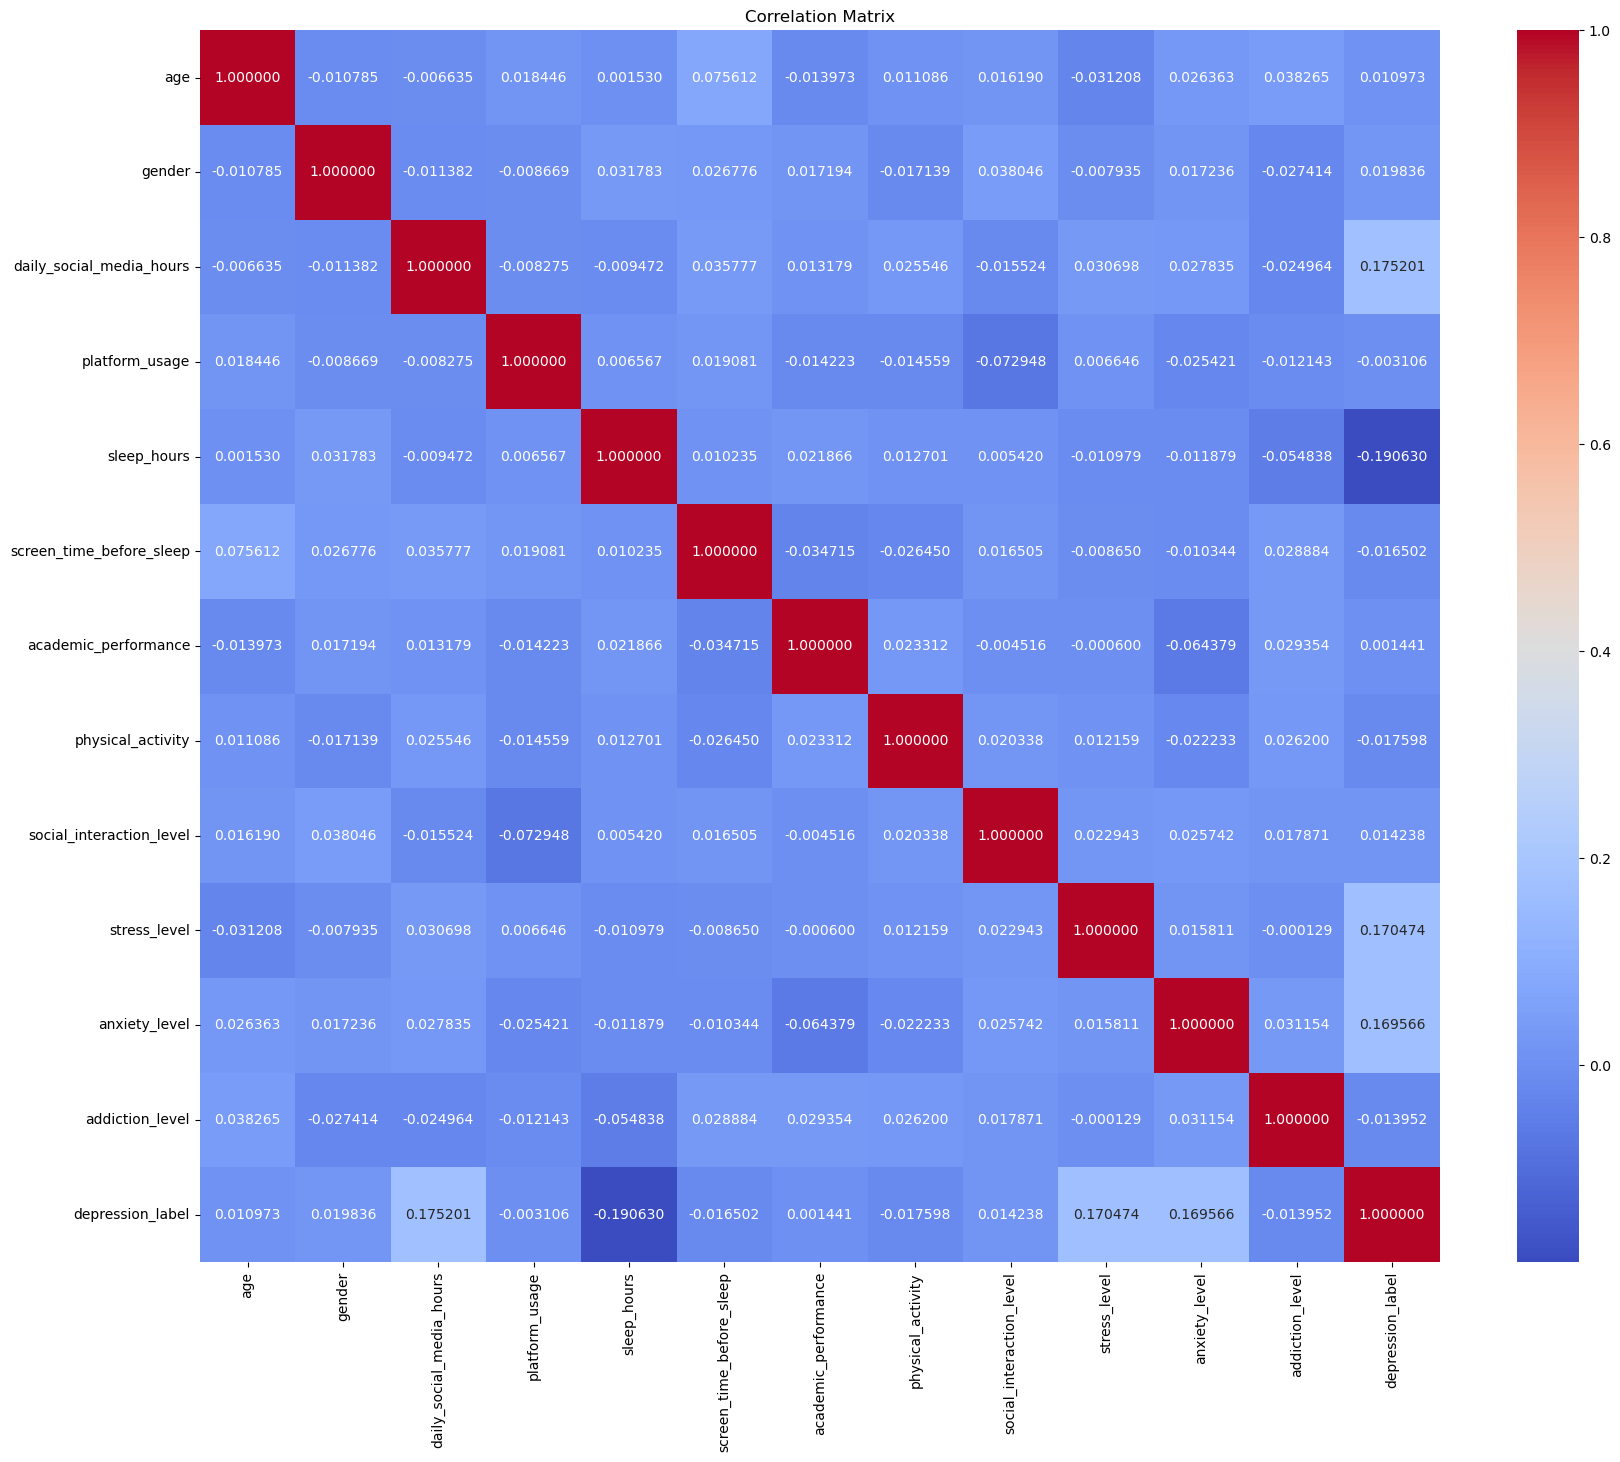

In [55]:
plt.figure(figsize=(20,16))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='2f')
plt.title('Correlation Matrix')
plt.show()

In [65]:
danger_zone = df.pivot_table(index = 'stress_level',
                             columns='age',
                             values='depression_label',
                             aggfunc='mean')

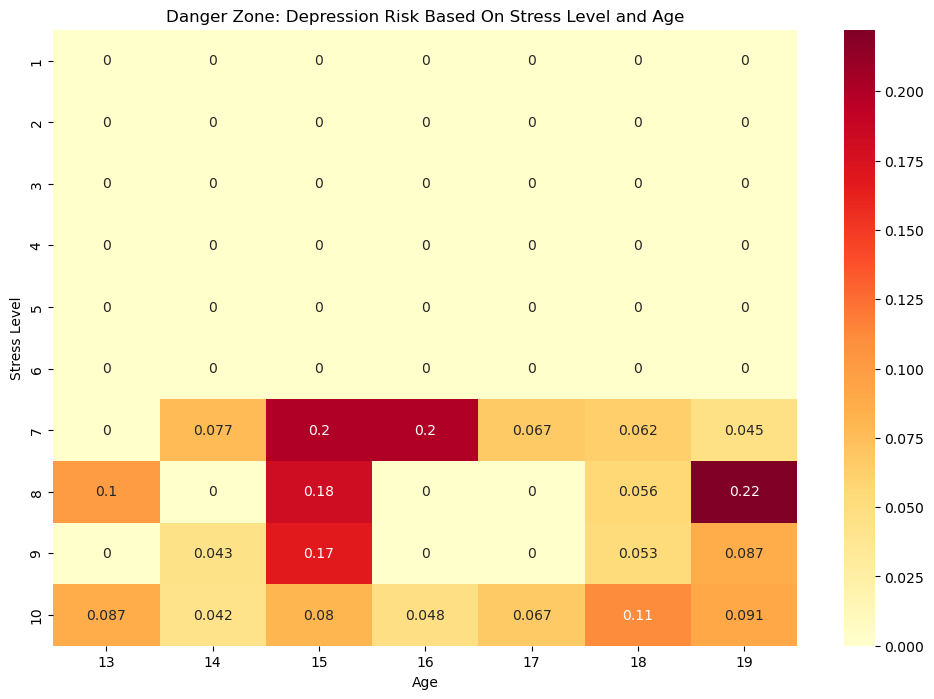

In [82]:
plt.figure(figsize=(12,8))
sns.heatmap(danger_zone, annot=True, cmap='YlOrRd')

plt.title('Danger Zone: Depression Risk Based On Stress Level and Age')
plt.xlabel('Age')
plt.ylabel('Stress Level')
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23308\609720501.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='depression_label', y='academic_performance', palette='Set2')


ValueError: The number of FixedLocator locations (2), usually from a call to set_ticks, does not match the number of labels (1).

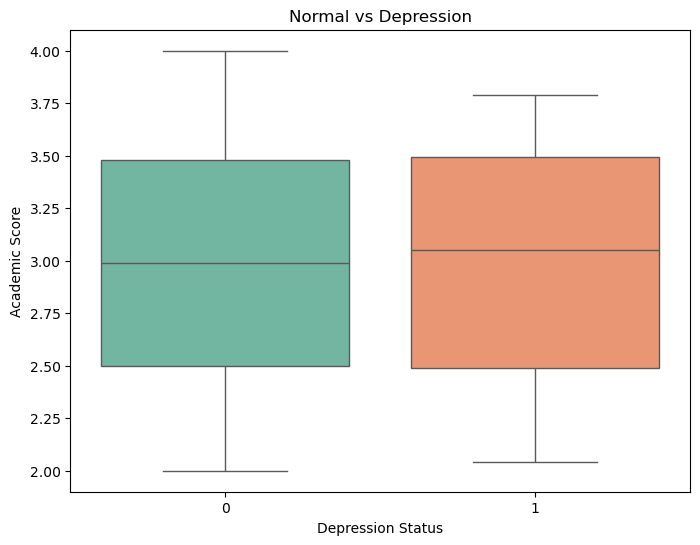

In [84]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='depression_label', y='academic_performance', palette='Set2')

plt.title('Normal vs Depression')
plt.xlabel('Depression Status')
plt.ylabel('Academic Score')
plt.xticks([0,1], ['Normal, Depression'])